# ABI-DAGAR versus matched MCMC-DAGAR

This notebook compares the frozen ABI posterior operator with the single-chain MCMC sampler targeting the same priors and generative construction. The comparison covers recovery, marginal posterior distance and width, joint dependence, boundary probabilities, runtime, and MCMC precision.

In [1]:
from pathlib import Path
import os
import sys

from IPython.display import display

def find_repository_root(start=None):
    current = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in (current, *current.parents):
        marker = candidate / 'Simulation Experiments' / 'ABI_vs_matched_MCMC' / 'matched_comparison.py'
        if marker.exists():
            return candidate
    raise FileNotFoundError('Could not locate the ABI_poisson_regression repository root.')

REPOSITORY_ROOT = find_repository_root()
EXPERIMENT_DIR = REPOSITORY_ROOT / 'Simulation Experiments' / 'ABI_vs_matched_MCMC'
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from matched_comparison import (
    plot_edge_agreement,
    plot_error_decomposition,
    plot_parameter_summary,
    plot_posterior_agreement,
    run_comparison,
)

BENCHMARK_DIR = EXPERIMENT_DIR / 'datasets' / 'benchmark_bank_seed123_n100'
ABI_RESULTS_DIR = Path(os.environ.get(
    'ABI_MATCHED_ABI_RESULTS_DIR', BENCHMARK_DIR / 'abi_results_all100'
))
MCMC_RESULTS_DIR = Path(os.environ.get(
    'ABI_MATCHED_MCMC_RESULTS_DIR', BENCHMARK_DIR / 'matched_mcmc_results_all100'
))
OUTPUT_DIR = Path(os.environ.get(
    'ABI_MATCHED_COMPARISON_DIR', BENCHMARK_DIR / 'comparison_abi_vs_matched_mcmc'
))

BENCHMARK_DIR, OUTPUT_DIR

(WindowsPath('C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Simulation Experiments/ABI_vs_matched_MCMC/datasets/benchmark_bank_seed123_n100'),
 WindowsPath('C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Simulation Experiments/ABI_vs_matched_MCMC/datasets/benchmark_bank_seed123_n100/comparison_abi_vs_matched_mcmc'))

## 1. Build paired comparison tables

In [2]:
tables = run_comparison(
    benchmark_dir=BENCHMARK_DIR,
    abi_results_dir=ABI_RESULTS_DIR,
    mcmc_results_dir=MCMC_RESULTS_DIR,
    output_dir=OUTPUT_DIR,
)
display(tables['parameter_method_summary'])
display(tables['parameter_agreement_summary'])

Compared posterior draws for 10/100 datasets


Compared posterior draws for 20/100 datasets


Compared posterior draws for 30/100 datasets


Compared posterior draws for 40/100 datasets


Compared posterior draws for 50/100 datasets


...

Compared posterior draws for 80/100 datasets


Compared posterior draws for 90/100 datasets


Compared posterior draws for 100/100 datasets


,method,parameter,n_datasets,mean_bias,mean_abs_error,median_abs_error,coverage_95,mean_posterior_sd,mean_interval_width
0,ABI,beta0,100,-0.003675,0.018558,0.011735,0.90,0.034647,0.098740
1,ABI,eta,100,-0.020210,0.114517,0.100018,0.95,0.143061,0.525840
2,ABI,eta_raw,100,-0.030811,0.158108,0.138039,0.95,0.198858,0.730871
3,ABI,rho,100,-0.024906,0.098613,0.080756,0.96,0.132964,0.488467
4,ABI,sigma2_w,100,0.005529,0.109694,0.085163,0.96,0.153323,0.571008
5,Matched MCMC,beta0,100,0.000941,0.012986,0.009146,0.89,0.013032,0.051149
6,Matched MCMC,eta,100,-0.032283,0.081171,0.055303,0.94,0.095666,0.345176
7,Matched MCMC,eta_raw,100,-0.046634,0.113128,0.082061,0.94,0.132771,0.479890
8,Matched MCMC,rho,100,0.008213,0.077927,0.061115,0.90,0.088168,0.333744
9,Matched MCMC,sigma2_w,100,0.036460,0.115907,0.086784,0.89,0.131955,0.502198


,parameter,n_datasets,mean_abs_posterior_mean_difference,median_abs_posterior_mean_difference,mean_abs_posterior_median_difference,median_width_ratio_abi_to_mcmc,mean_interval_overlap_fraction,posterior_mean_correlation
0,beta0,100,0.011181,0.006462,0.011166,1.528713,0.958608,0.999687
1,eta,100,0.076877,0.065927,0.084212,1.565701,0.986015,0.834783
2,eta_raw,100,0.105942,0.087613,0.116216,1.565701,0.986015,0.843495
3,rho,100,0.074452,0.051912,0.074222,1.405322,0.948180,0.932856
4,sigma2_w,100,0.067513,0.041415,0.062733,1.149665,0.948017,0.958517


## 2. Posterior-mean error decomposition

For each primitive parameter, the empirical squared ABI error is decomposed as

$$\left(\widehat\theta_{\mathrm{ABI}}-\theta\right)^2 = \left(\widehat\theta_{\mathrm{MCMC}}-\theta\right)^2 + \left(\widehat\theta_{\mathrm{ABI}}-\widehat\theta_{\mathrm{MCMC}}\right)^2 + 2\left(\widehat\theta_{\mathrm{MCMC}}-\theta\right)\left(\widehat\theta_{\mathrm{ABI}}-\widehat\theta_{\mathrm{MCMC}}\right).$$

The controlled components remove the estimated finite-draw variances of both posterior-mean estimates. Under independent, mean-zero Monte Carlo error, the MCMC variance is removed from the reference term, both variances are removed from the discrepancy term, and twice the MCMC variance is added to the interaction term.

,parameter,abi_total_mse_mc_corrected,mcmc_reference_mse_mc_corrected,approximation_mse_mc_corrected,interaction_mc_corrected,mean_abi_mc_variance,mean_mcmc_mc_variance,mc_variance_pct_of_observed_approximation_mse,decomposition_residual
0,beta0,0.000652,0.000322,0.000278,0.000052,3.131137e-07,6.071096e-07,0.329383,-1.843144e-18
1,sigma2_w,0.028719,0.029349,0.010089,-0.010719,2.756480e-06,3.402511e-04,3.288041,-2.081668e-17
2,eta_raw,0.040767,0.026339,0.016421,-0.001993,4.285969e-06,1.565138e-04,0.969731,6.938894e-18
3,rho,0.017392,0.010907,0.009926,-0.003441,2.067983e-06,1.000586e-04,1.018381,-1.040834e-17


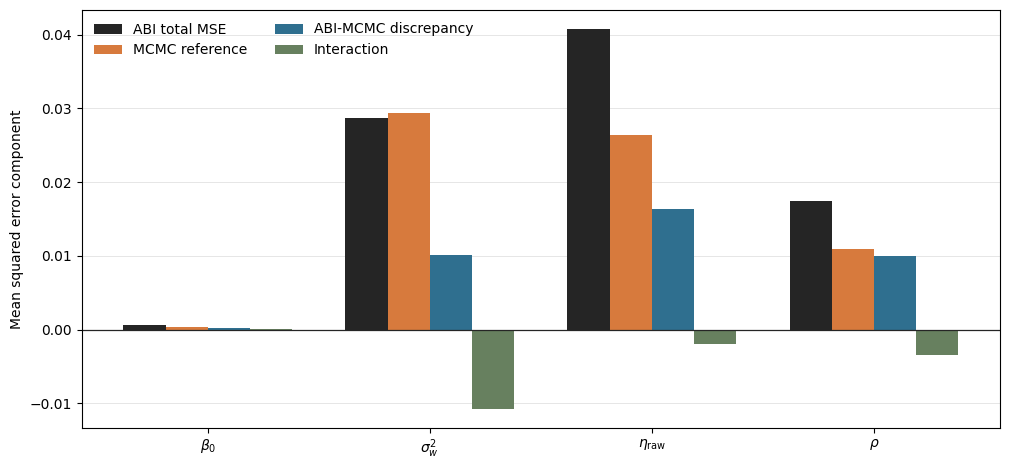

In [3]:
decomposition_columns = [
    'parameter',
    'abi_total_mse_mc_corrected',
    'mcmc_reference_mse_mc_corrected',
    'approximation_mse_mc_corrected',
    'interaction_mc_corrected',
    'mean_abi_mc_variance',
    'mean_mcmc_mc_variance',
    'mc_variance_pct_of_observed_approximation_mse',
    'decomposition_residual',
]
display(tables['error_decomposition_summary'][decomposition_columns])
plot_error_decomposition(tables, OUTPUT_DIR);

## 3. Marginal and joint posterior agreement

,parameter,n_datasets,mean_wasserstein,median_wasserstein,mean_scaled_wasserstein,median_scaled_wasserstein,mean_ks,median_ks
0,beta0,100,0.014638,0.009085,1.404810,0.845359,0.296015,0.25005
1,eta,100,0.088715,0.083158,1.604492,0.991057,0.374572,0.37645
2,eta_raw,100,0.122999,0.116578,1.604492,0.991057,0.374572,0.37645
3,rho,100,0.079986,0.054242,1.154355,0.586691,0.288765,0.23445
4,sigma2_w,100,0.071831,0.048603,0.691303,0.403504,0.237579,0.17975


,correlation_frobenius_difference,maximum_absolute_correlation_difference
count,100.000000,100.000000
mean,0.321248,0.162930
std,0.128111,0.071889
min,0.096524,0.042011
25%,0.229169,0.113839
50%,0.316438,0.153716
75%,0.380221,0.194876
max,0.752769,0.451347


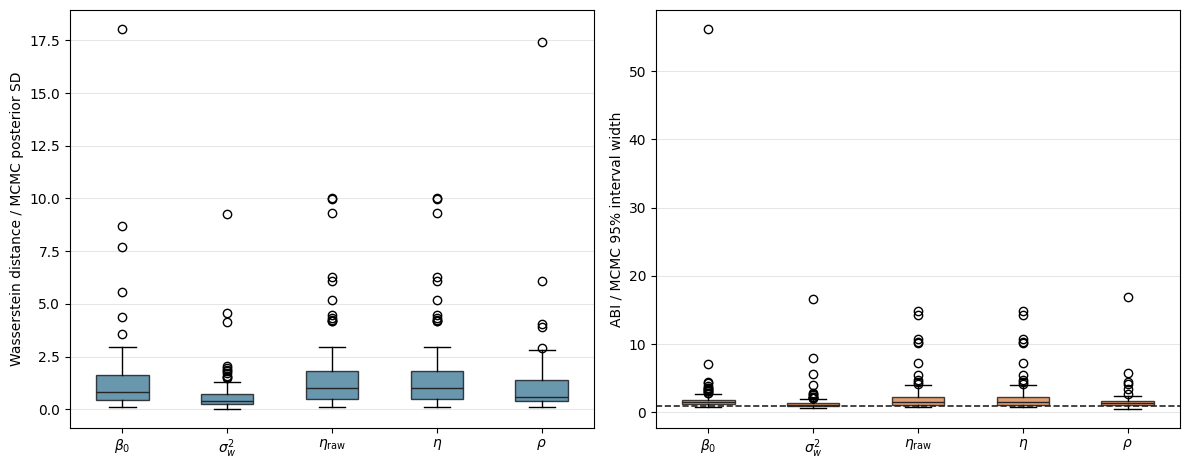

In [4]:
display(tables['posterior_marginal_distance_summary'])
display(tables['posterior_joint_correlation_differences'].describe())
plot_posterior_agreement(tables, OUTPUT_DIR);

## 4. Recovery and interval calibration

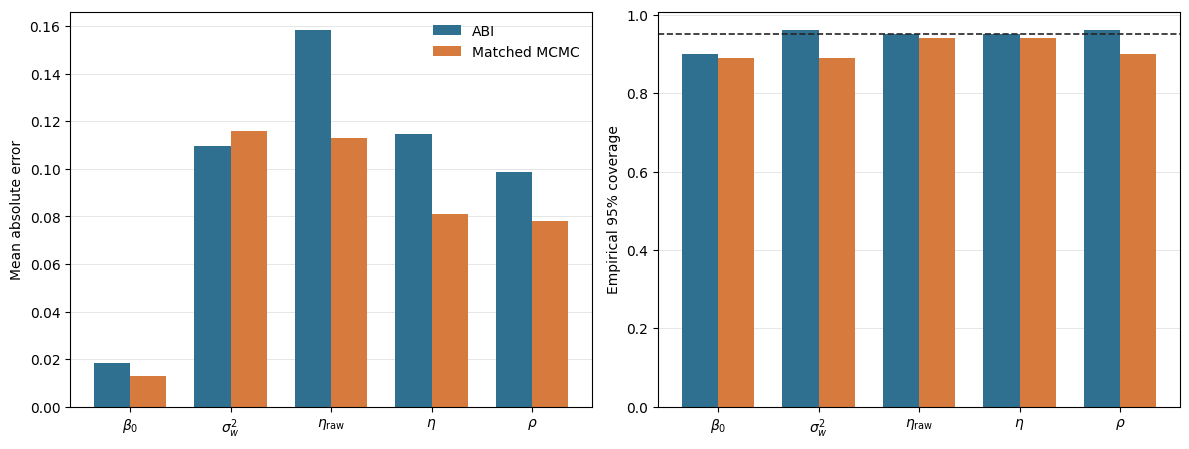

In [5]:
plot_parameter_summary(tables, OUTPUT_DIR);

## 5. Edge-level boundary agreement

,n_datasets,mean_probability_correlation,median_probability_correlation,mean_probability_mae,median_probability_mae,mean_jaccard,median_jaccard
0,100,0.906022,0.946197,0.074501,0.068776,0.571034,0.678282


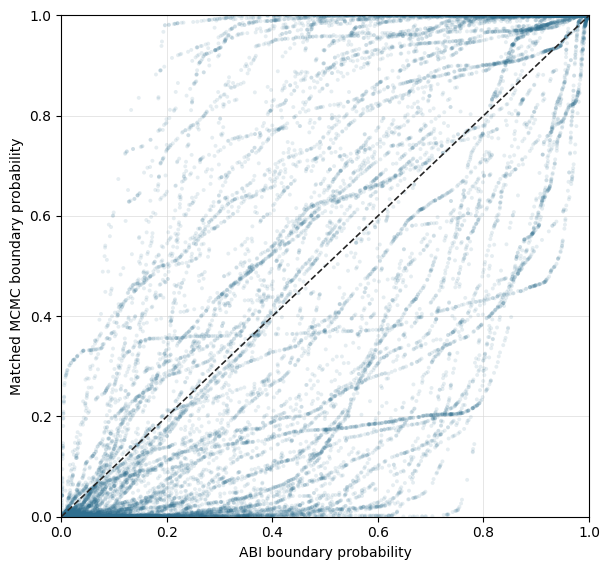

In [6]:
display(tables['edge_agreement_summary'])
plot_edge_agreement(tables, OUTPUT_DIR);

## 6. Runtime and single-chain MCMC diagnostics

In [7]:
display(tables['runtime_summary'])
display(tables['mcmc_chain_diagnostics'].groupby('parameter')[['effective_sample_size', 'mcse_over_posterior_sd']].describe())
display(tables['mcmc_acceptance'].groupby('parameter')['acceptance_rate'].describe())

,index,elapsed_sec_abi,elapsed_sec_mcmc,mcmc_to_abi_runtime_ratio
0,mean,0.771502,2.7075,3.578259
1,median,0.737823,2.6200,3.502701


effective_sample_size                                      \
                          count        mean         std         min   
parameter                                                             
beta0                     100.0  461.647693  163.930333  148.055549   
eta                       100.0  821.517169  686.617291    7.810169   
eta_raw                   100.0  821.517169  686.617291    7.810169   
rho                       100.0  302.391811  337.094082   11.064298   
sigma2_w                  100.0  320.371554  357.681758    7.358220   

                                                             \
                  25%         50%          75%          max   
parameter                                                     
beta0      346.794791  448.750918   573.287908   930.449054   
eta        191.027658  626.121440  1290.645585  2430.436829   
eta_raw    191.027658  626.121440  1290.645585  2430.436829   
rho         73.714528  173.133566   380.658772  1593.654973   
sigma2_w    59.896645  160.443963   467.007864  1481.279481   

          mcse_over_posterior_sd                                          \
                           count      mean       std       min       25%   
parameter                                                                  
beta0                      100.0  0.049022  0.009768  0.032783  0.041765   
eta                        100.0  0.058735  0.052241  0.020284  0.027837   
eta_raw                    100.0  0.058735  0.052241  0.020284  0.027837   
rho                        100.0  0.091315  0.057637  0.025050  0.051258   
sigma2_w                   100.0  0.095670  0.064031  0.025983  0.046276   

                                         
                50%       75%       max  
parameter                                
beta0      0.047210  0.053705  0.082184  
eta        0.039964  0.072352  0.357824  
eta_raw    0.039964  0.072352  0.357824  
rho        0.076003  0.116517  0.300634  
sigma2_w   0.078948  0.129224  0.368649

,count,mean,std,min,25%,50%,75%,max
parameter,,,,,,,,
beta0,100.0,0.350420,0.017624,0.310900,0.338275,0.349650,0.362350,0.400550
eta,100.0,0.545253,0.106461,0.420400,0.471988,0.502475,0.583787,0.877050
field,100.0,0.464996,0.015872,0.412396,0.458274,0.467782,0.475810,0.494521
rho,100.0,0.370085,0.023607,0.323000,0.354825,0.366800,0.384263,0.452050
sigma2_w,100.0,0.363855,0.017772,0.317450,0.350950,0.362375,0.376287,0.404950
